In [1]:
import pandas as pd

data = pd.read_csv("C:/Users/Dell5371/Downloads/final_dataset.csv", encoding = 'cp949')

data.head()

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥),연도,월,일,시각,계절
0,108,서울,2025-04-20 01:00:00,11.6,0.0,1.0,270,93,999.4,0,0,16,2025,4,20,1,봄
1,108,서울,2025-04-20 02:00:00,11.2,0.0,1.3,290,94,999.2,0,0,12,2025,4,20,2,봄
2,108,서울,2025-04-20 03:00:00,10.6,0.0,2.2,270,95,999.6,2,2,17,2025,4,20,3,봄
3,108,서울,2025-04-20 04:00:00,10.1,0.0,1.4,250,93,999.6,0,0,10,2025,4,20,4,봄
4,108,서울,2025-04-20 05:00:00,9.7,0.0,0.6,320,94,999.9,0,0,19,2025,4,20,5,봄


In [2]:
data.describe()

,지점,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥),연도,월,일,시각
count,8248.0,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000,8248.000000
mean,108.0,14.061785,0.124673,2.272333,188.358390,63.545587,1005.673424,4.629486,3.131183,32.724782,2025.306256,6.460233,15.707808,11.507396
std,0.0,11.452519,1.056308,1.045362,104.358499,18.820754,8.245494,4.043202,3.601195,21.288964,0.460965,3.480043,8.846849,6.891506
min,108.0,-13.100000,0.000000,0.000000,0.000000,14.000000,983.000000,0.000000,0.000000,0.000000,2025.000000,1.000000,1.000000,0.000000
25%,108.0,4.800000,0.000000,1.500000,70.000000,49.000000,999.500000,0.000000,0.000000,18.000000,2025.000000,3.000000,8.000000,6.000000
50%,108.0,14.700000,0.000000,2.200000,230.000000,64.000000,1005.250000,5.000000,1.000000,29.000000,2025.000000,6.000000,16.000000,12.000000
75%,108.0,24.000000,0.000000,2.900000,270.000000,79.000000,1012.900000,9.000000,7.000000,42.000000,2026.000000,9.000000,23.000000,17.000000
max,108.0,37.600000,35.200000,7.700000,360.000000,100.000000,1022.500000,10.000000,10.000000,348.000000,2026.000000,12.000000,31.000000,23.000000


In [3]:
data['일시'] = pd.to_datetime(data['일시'])

In [4]:
def get_term(date):

    year = date.year

    ipchun = pd.Timestamp(f'{year}-02-03')
    ipha = pd.Timestamp(f'{year}-05-05')
    ipchu = pd.Timestamp(f'{year}-08-07')
    ipdong = pd.Timestamp(f'{year}-11-07')

    if ipchun <= date < ipha:
        return '입춘'
    elif ipha <= date < ipchu:
        return '입하'
    elif ipchu <= date < ipdong:
        return '입추'
    else:
        return '입동'

data['절기'] = data['일시'].apply(get_term)

In [5]:
data.head()

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥),연도,월,일,시각,계절,절기
0,108,서울,2025-04-20 01:00:00,11.6,0.0,1.0,270,93,999.4,0,0,16,2025,4,20,1,봄,입춘
1,108,서울,2025-04-20 02:00:00,11.2,0.0,1.3,290,94,999.2,0,0,12,2025,4,20,2,봄,입춘
2,108,서울,2025-04-20 03:00:00,10.6,0.0,2.2,270,95,999.6,2,2,17,2025,4,20,3,봄,입춘
3,108,서울,2025-04-20 04:00:00,10.1,0.0,1.4,250,93,999.6,0,0,10,2025,4,20,4,봄,입춘
4,108,서울,2025-04-20 05:00:00,9.7,0.0,0.6,320,94,999.9,0,0,19,2025,4,20,5,봄,입춘


In [6]:
data.columns

Index(['지점', '지점명', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)',
       '현지기압(hPa)', '전운량(10분위)', '중하층운량(10분위)', '1시간평균 미세먼지농도(㎍/㎥)', '연도', '월',
       '일', '시각', '계절', '절기'],
      dtype='str')

In [7]:
data.dtypes

지점                            int64
지점명                             str
일시                   datetime64[us]
기온(°C)                      float64
강수량(mm)                     float64
풍속(m/s)                     float64
풍향(16방위)                      int64
습도(%)                         int64
현지기압(hPa)                   float64
전운량(10분위)                     int64
중하층운량(10분위)                   int64
1시간평균 미세먼지농도(㎍/㎥)             int64
연도                            int64
월                             int64
일                             int64
시각                            int64
계절                              str
절기                              str
dtype: object

##### **상관관계 분석:**
- 미세먼지 농도 제외하고 나머지 컬럼들끼리 비교할 때 서로 영향을 주는 변수
- 상관관계의 경우 수치형 데이터만 사용 가능, 지점의 경우 지점명 '서울'에 대한 코드이므로 사용 X
    - [기온 / 강수량 / 풍속 / 풍향 / 습도 / 현지기압 / 전운량]

In [8]:
data.columns

Index(['지점', '지점명', '일시', '기온(°C)', '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)',
       '현지기압(hPa)', '전운량(10분위)', '중하층운량(10분위)', '1시간평균 미세먼지농도(㎍/㎥)', '연도', '월',
       '일', '시각', '계절', '절기'],
      dtype='str')

In [11]:
df = data.drop(columns=['지점명', '지점', '일시', '계절', '절기', '연도', '월', '일', '시각'])

In [12]:
df.corr(method='pearson')


,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥)
기온(°C),1.000000,0.063044,0.020657,-0.092770,0.234029,-0.775772,0.301285,0.179031,-0.174270
강수량(mm),0.063044,1.000000,0.034483,-0.036857,0.184534,-0.094145,0.150435,0.155285,-0.079127
풍속(m/s),0.020657,0.034483,1.000000,0.158274,-0.296460,-0.054141,0.000810,0.006553,0.053411
풍향(16방위),-0.092770,-0.036857,0.158274,1.000000,-0.203933,0.025534,-0.207439,-0.159544,0.104840
습도(%),0.234029,0.184534,-0.296460,-0.203933,1.000000,-0.358817,0.413043,0.448544,-0.236656
현지기압(hPa),-0.775772,-0.094145,-0.054141,0.025534,-0.358817,1.000000,-0.343773,-0.267300,0.118183
전운량(10분위),0.301285,0.150435,0.000810,-0.207439,0.413043,-0.343773,1.000000,0.799671,-0.122643
중하층운량(10분위),0.179031,0.155285,0.006553,-0.159544,0.448544,-0.267300,0.799671,1.000000,-0.122779
1시간평균 미세먼지농도(㎍/㎥),-0.174270,-0.079127,0.053411,0.104840,-0.236656,0.118183,-0.122643,-0.122779,1.000000


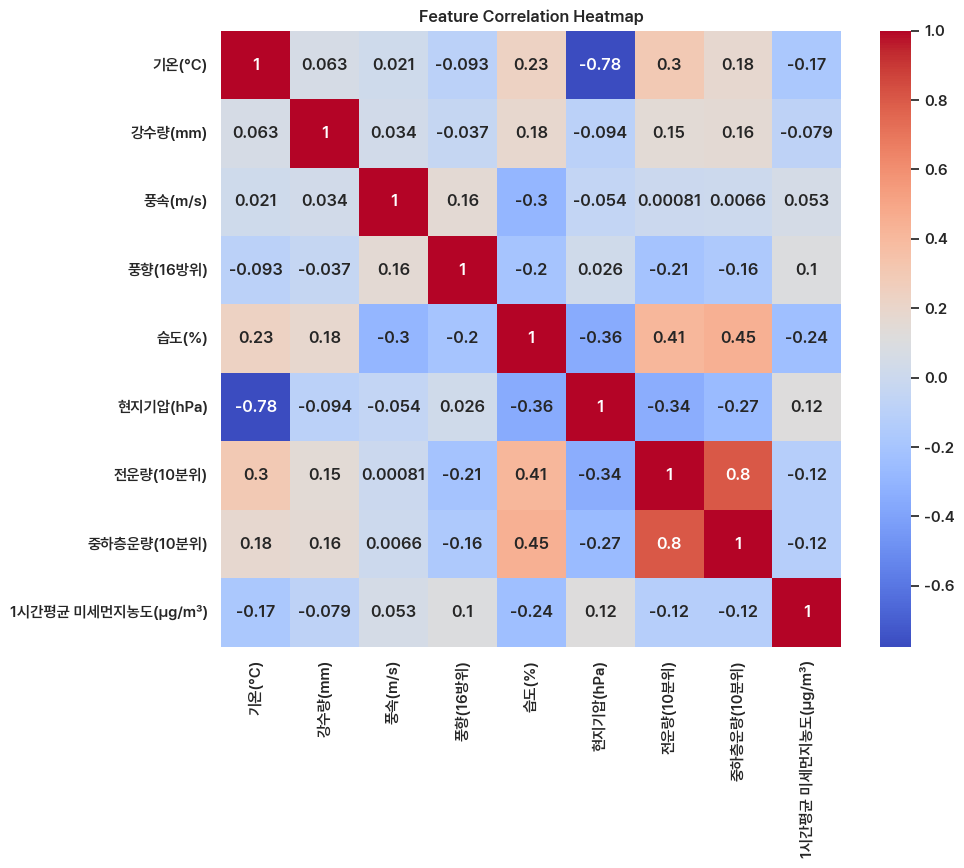

In [13]:
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt


font_path = 'C:/Users/Dell5371/AppData/Local/Microsoft/Windows/Fonts/Pretendard-SemiBold.otf'
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

전운량과 중하층운량 : 강한 양의 상관관계를 가짐

기온과 현지기압 : 강한 음의 상관관계를 가짐

-->> 활용 ? or drop?

#### 풍향과 황사농도의 관계

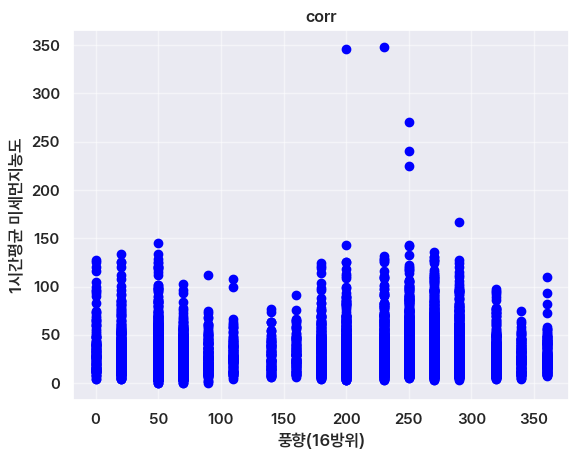

In [14]:
temp = df['풍향(16방위)']
dust = df['1시간평균 미세먼지농도(㎍/㎥)']

# 산점도 그리기
plt.scatter(temp, dust, color='blue', marker='o')

# 그래프 제목 및 축 레이블
plt.title("corr")
plt.xlabel("풍향(16방위)")
plt.ylabel("1시간평균 미세먼지농도")

# 그래프 보여주기
plt.show()

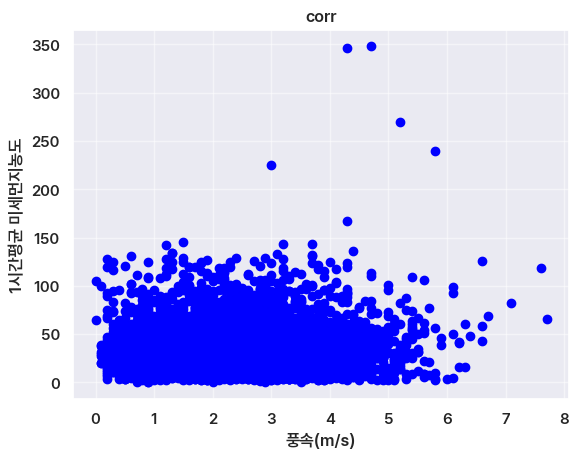

In [15]:
temp = df['풍속(m/s)']
dust = df['1시간평균 미세먼지농도(㎍/㎥)']

# 산점도 그리기
plt.scatter(temp, dust, color='blue', marker='o')

# 그래프 제목 및 축 레이블
plt.title("corr")
plt.xlabel("풍속(m/s)")
plt.ylabel("1시간평균 미세먼지농도")

# 그래프 보여주기
plt.show()

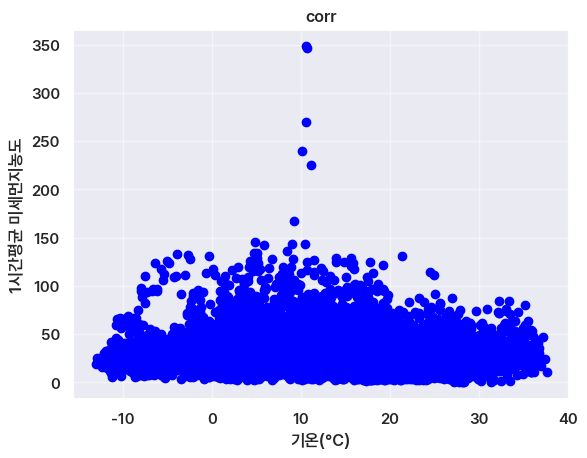

In [16]:
temp = df['기온(°C)']
dust = df['1시간평균 미세먼지농도(㎍/㎥)']

# 산점도 그리기
plt.scatter(temp, dust, color='blue', marker='o')

# 그래프 제목 및 축 레이블
plt.title("corr")
plt.xlabel("기온(°C)")
plt.ylabel("1시간평균 미세먼지농도")

# 그래프 보여주기
plt.show()

지금까지 계절의 특성을 안나누고 진행해보았다면,,
이제부턴 계절별로 시각화해보자!

In [17]:
spring = data[data['계절']=='봄']
summer = data[data['계절']=='여름']
autumn = data[data['계절']=='가을']
winter = data[data['계절']=='겨울']

In [18]:

ipchoon = data[data['절기']=='입춘']
ipha = data[data['절기']=='입하']
ipchoo = data[data['절기']=='입추']
ipdong = data[data['절기']=='입동']

In [19]:
print('spring shape: ', spring.shape)
print('summer shape: ', summer.shape)
print('autumn shape: ', autumn.shape)
print('winter shape: ', winter.shape)

print('ipchoon shape: ', ipchoon.shape)
print('ipha shape: ', ipha.shape)
print('ipchoo shape: ', ipchoo.shape)
print('ipdong shape: ', ipdong.shape)



spring shape:  (2090, 18)
summer shape:  (2054, 18)
autumn shape:  (1976, 18)
winter shape:  (2128, 18)
ipchoon shape:  (2075, 18)
ipha shape:  (2152, 18)
ipchoo shape:  (1950, 18)
ipdong shape:  (2071, 18)


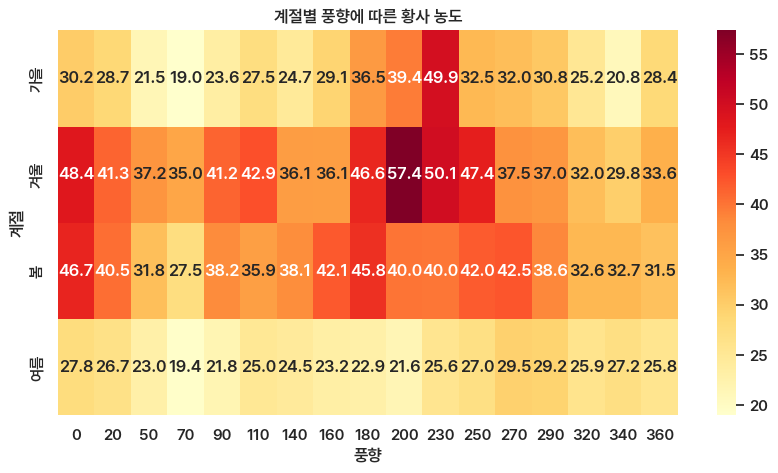

In [20]:
pivot = data.pivot_table(
    values='1시간평균 미세먼지농도(㎍/㎥)',
    index='계절',
    columns='풍향(16방위)',
    aggfunc='mean'
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd'
)

plt.title('계절별 풍향에 따른 황사 농도')
plt.xlabel('풍향')
plt.ylabel('계절')
plt.show()

풍향 0 - 20: 봄 , 겨울
풍향 90 - 110: 봄 , 겨울
풍향 160 - 270

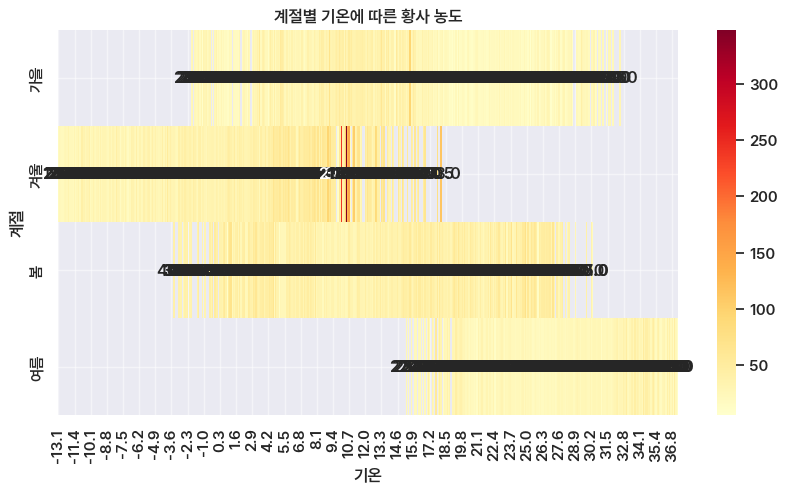

In [21]:
pivot = data.pivot_table(
    values='1시간평균 미세먼지농도(㎍/㎥)',
    index='계절',
    columns='기온(°C)',
    aggfunc='mean'
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd'
)

plt.title('계절별 기온에 따른 황사 농도')
plt.xlabel('기온')
plt.ylabel('계절')
plt.show()

In [22]:
bins = [0, 0.3, 1.5, 3.3, 5.5, 7.9, 10.7, float('inf')]
labels = ['0~0.3', '0.3~1.5', '1.5~3.3', '3.3~5.5', '5.5~7.9', '7.9~10.7','10.7+']

data['풍속구간'] = pd.cut(data['풍속(m/s)'], bins=bins, labels=labels)

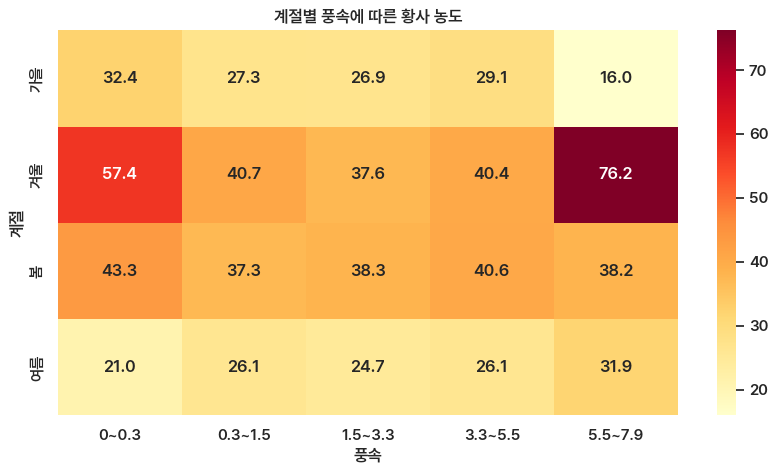

In [23]:
pivot = data.pivot_table(
    values='1시간평균 미세먼지농도(㎍/㎥)',
    index='계절',
    columns='풍속구간',
    aggfunc='mean'
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd'
)

plt.title('계절별 풍속에 따른 황사 농도')
plt.xlabel('풍속')
plt.ylabel('계절')
plt.show()

In [24]:
spring.head()

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥),연도,월,일,시각,계절,절기
0,108,서울,2025-04-20 01:00:00,11.6,0.0,1.0,270,93,999.4,0,0,16,2025,4,20,1,봄,입춘
1,108,서울,2025-04-20 02:00:00,11.2,0.0,1.3,290,94,999.2,0,0,12,2025,4,20,2,봄,입춘
2,108,서울,2025-04-20 03:00:00,10.6,0.0,2.2,270,95,999.6,2,2,17,2025,4,20,3,봄,입춘
3,108,서울,2025-04-20 04:00:00,10.1,0.0,1.4,250,93,999.6,0,0,10,2025,4,20,4,봄,입춘
4,108,서울,2025-04-20 05:00:00,9.7,0.0,0.6,320,94,999.9,0,0,19,2025,4,20,5,봄,입춘


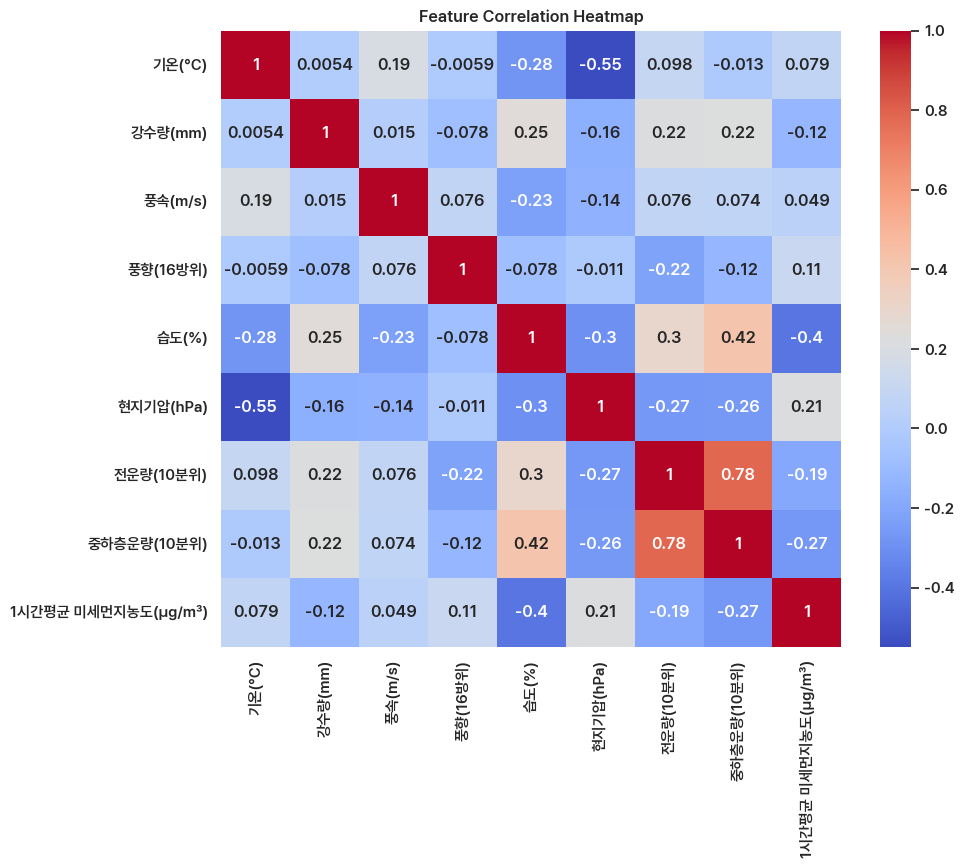

In [25]:
spring2 = spring.drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = spring2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

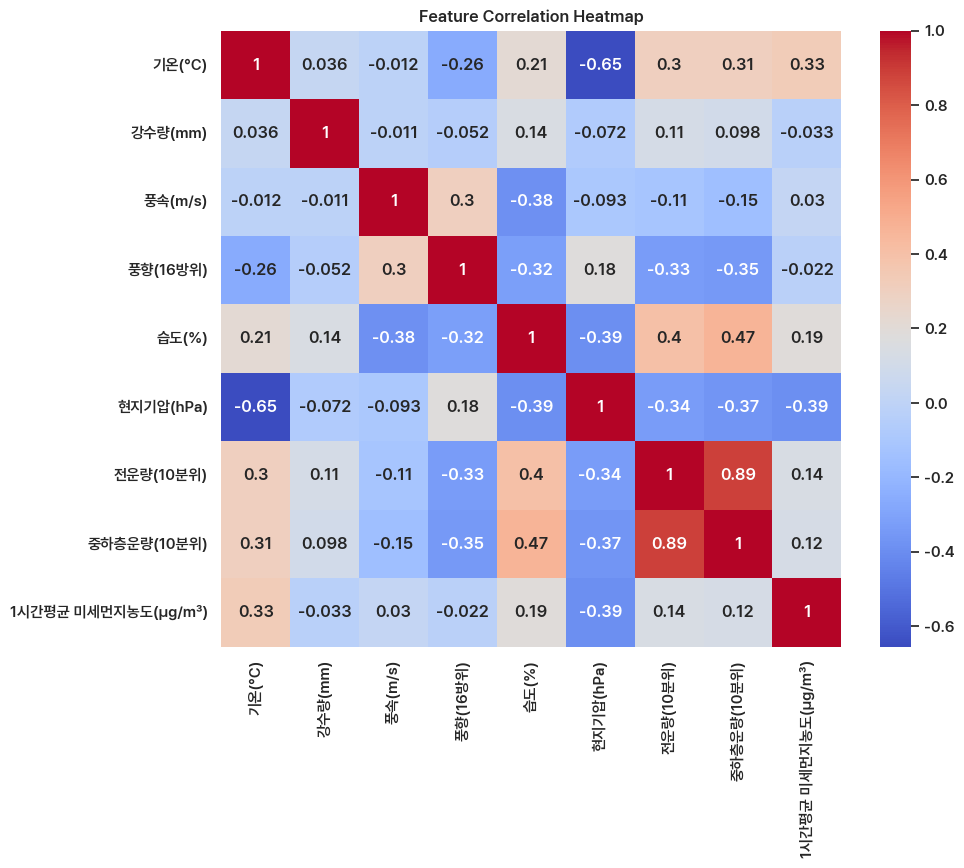

In [26]:
winter2 = winter.drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = winter2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

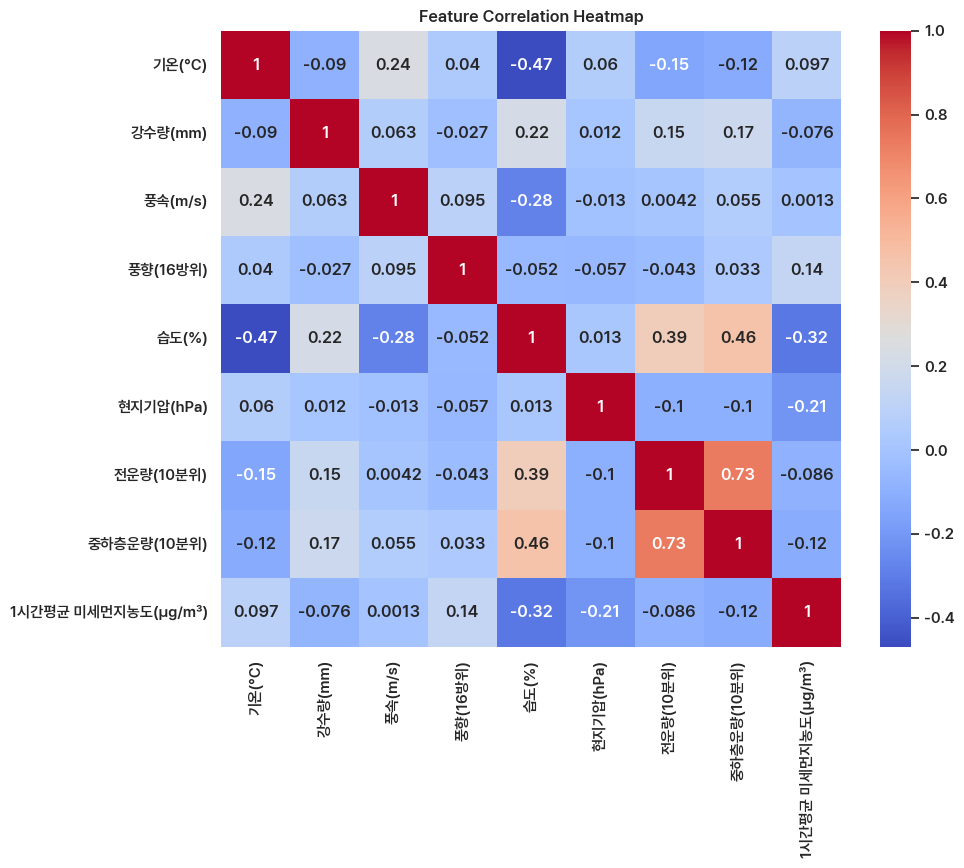

In [27]:
summer2 = summer.drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = summer2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

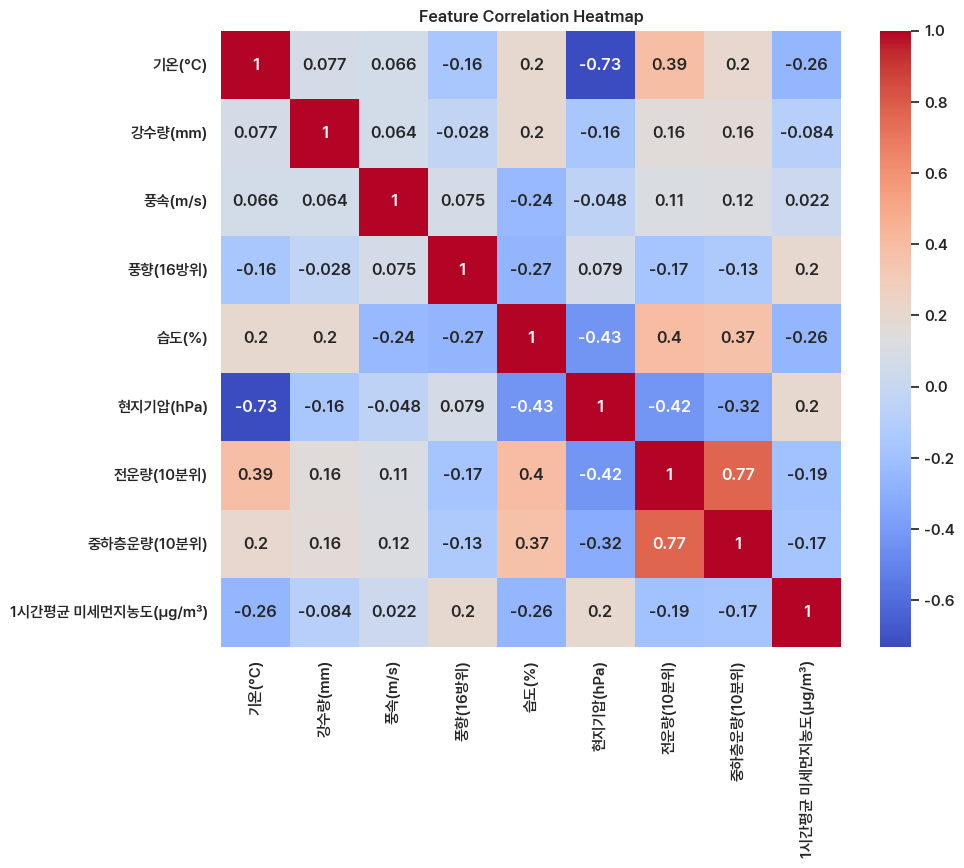

In [28]:
autumn2 = autumn.drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = autumn2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**spring**

Text(0, 0.5, '미세먼지 농도')

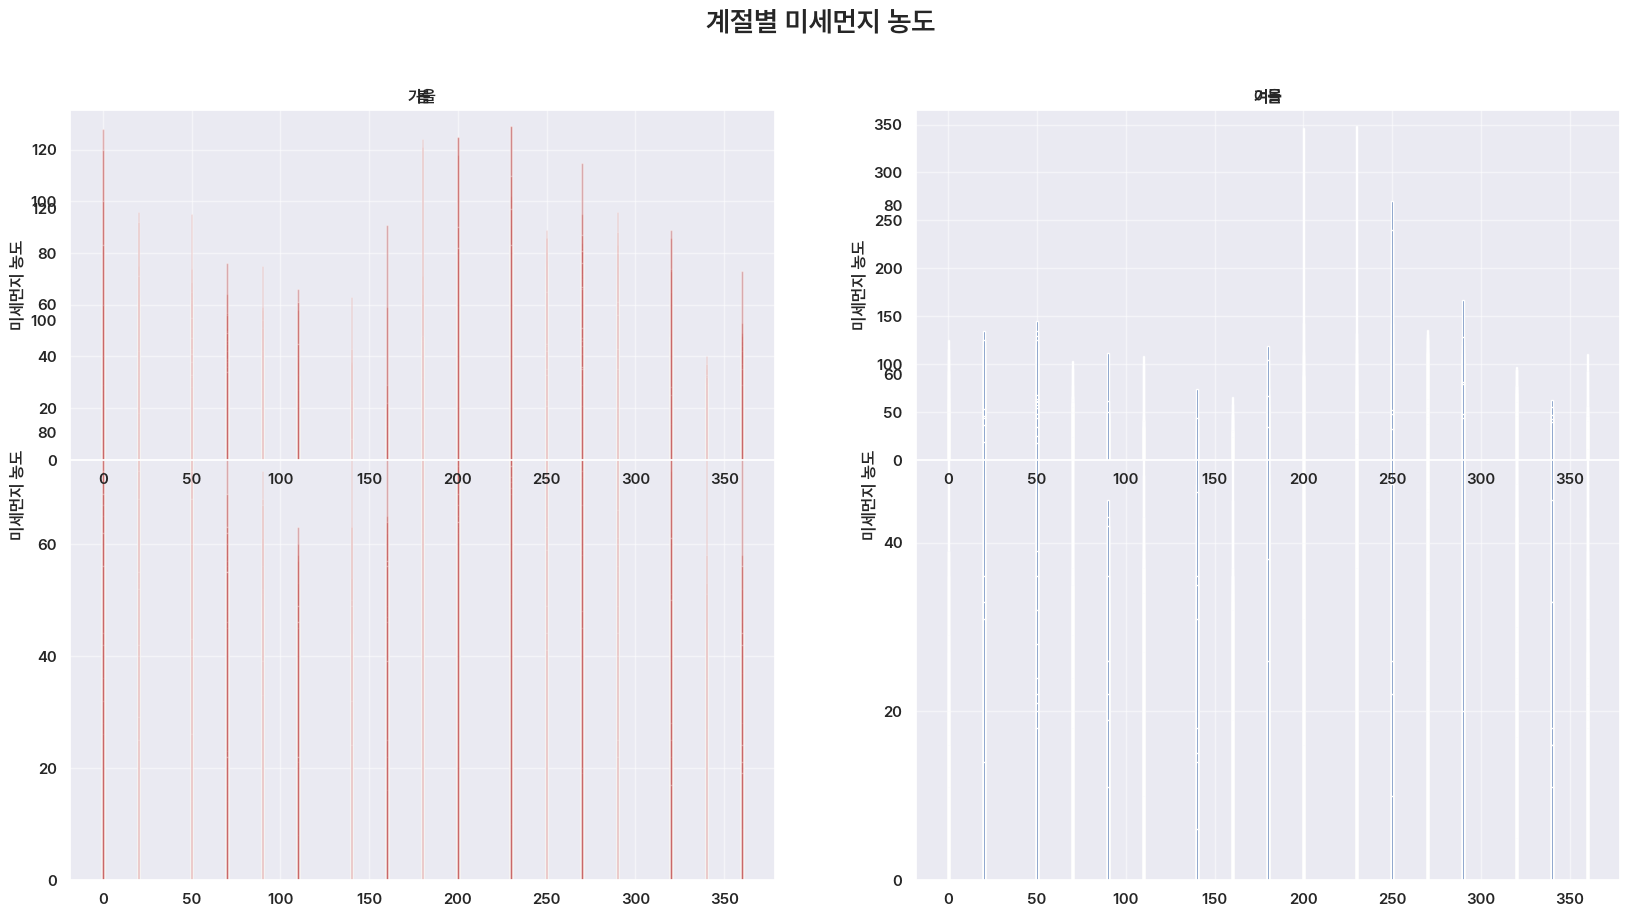

In [29]:
season = [spring, summer, autumn, winter]

plt.figure(figsize=(20, 10))
plt.suptitle('계절별 미세먼지 농도', fontsize = 20)

plt.subplot(1, 2, 1)
plt.bar(spring['풍향(16방위)'], spring['1시간평균 미세먼지농도(㎍/㎥)'], color = '#B22222', alpha = 0.4)
plt.title('봄')
plt.ylabel('미세먼지 농도')

plt.subplot(1, 2, 2)
plt.bar(summer['풍향(16방위)'], summer['1시간평균 미세먼지농도(㎍/㎥)'])
plt.title('여름')
plt.ylabel('미세먼지 농도')

plt.subplot(2, 2, 1)
plt.bar(autumn['풍향(16방위)'], autumn['1시간평균 미세먼지농도(㎍/㎥)'], color = '#B22222', alpha = 0.4)
plt.title('가을')
plt.ylabel('미세먼지 농도')

plt.subplot(2, 2, 2)
plt.bar(winter['풍향(16방위)'], winter['1시간평균 미세먼지농도(㎍/㎥)'])
plt.title('겨울')
plt.ylabel('미세먼지 농도')

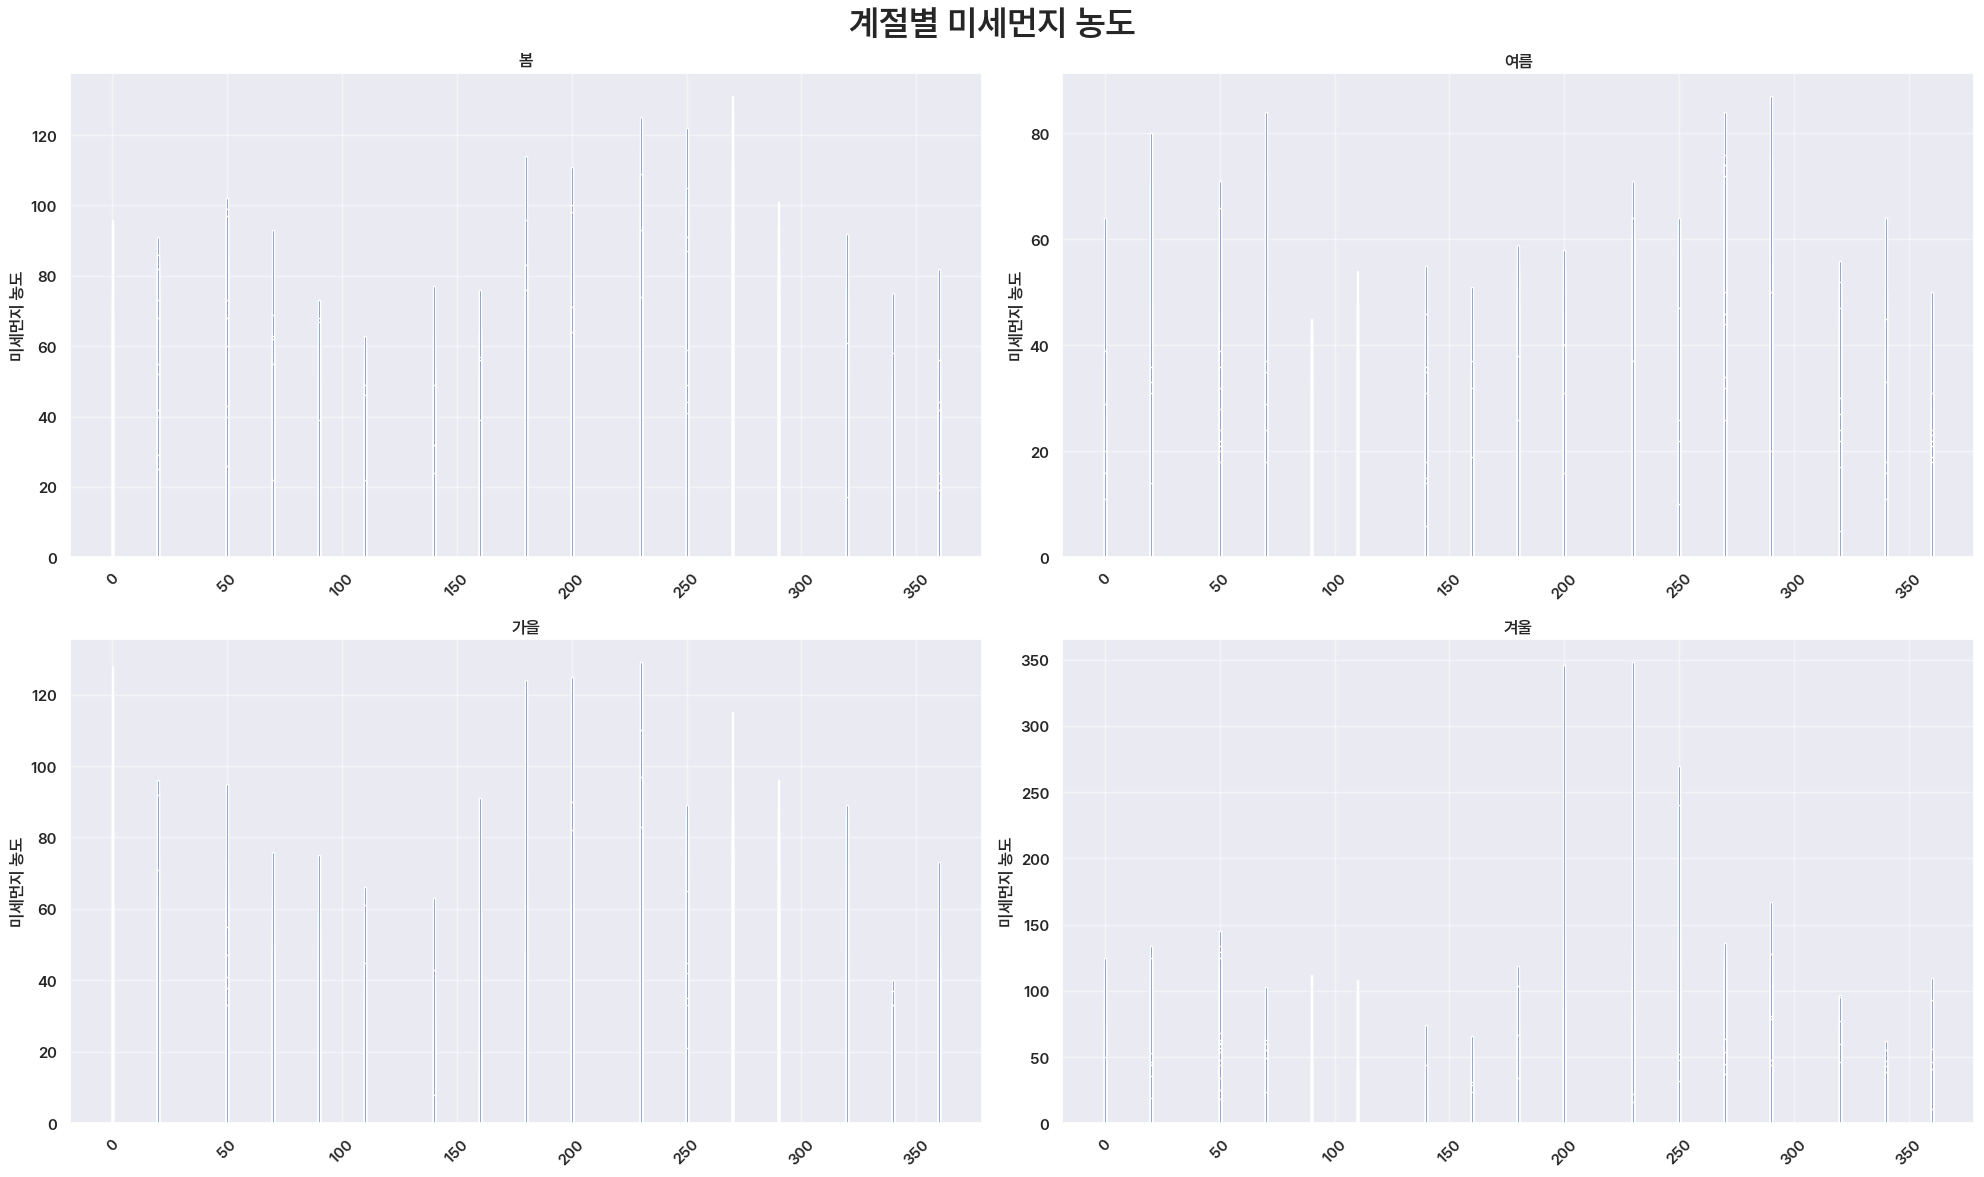

In [30]:
plt.figure(figsize=(20, 12))
plt.suptitle('계절별 미세먼지 농도', fontsize=25)

plt.subplot(2, 2, 1)
plt.bar(spring['풍향(16방위)'], spring['1시간평균 미세먼지농도(㎍/㎥)'])
plt.title('봄')
plt.ylabel('미세먼지 농도')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
plt.bar(summer['풍향(16방위)'], summer['1시간평균 미세먼지농도(㎍/㎥)'])
plt.title('여름')
plt.ylabel('미세먼지 농도')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
plt.bar(autumn['풍향(16방위)'], autumn['1시간평균 미세먼지농도(㎍/㎥)'])
plt.title('가을')
plt.ylabel('미세먼지 농도')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
plt.bar(winter['풍향(16방위)'], winter['1시간평균 미세먼지농도(㎍/㎥)'])
plt.title('겨울')
plt.ylabel('미세먼지 농도')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

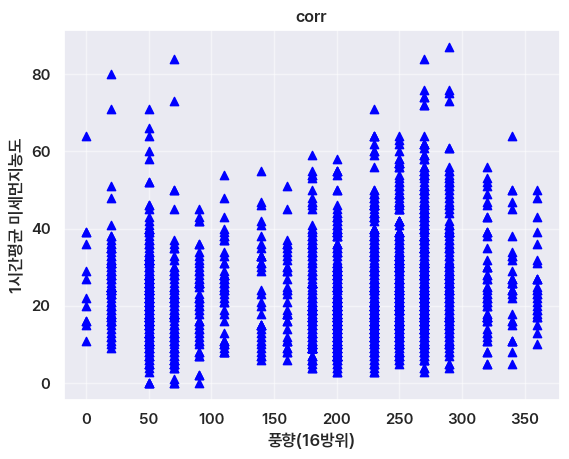

In [31]:
temp = summer['풍향(16방위)']
dust = summer['1시간평균 미세먼지농도(㎍/㎥)']

# 산점도 그리기
plt.scatter(temp, dust, color='blue', marker='^')

# 그래프 제목 및 축 레이블
plt.title("corr")
plt.xlabel("풍향(16방위)")
plt.ylabel("1시간평균 미세먼지농도")

# 그래프 보여주기
plt.show()

**절기에 따른 변화**

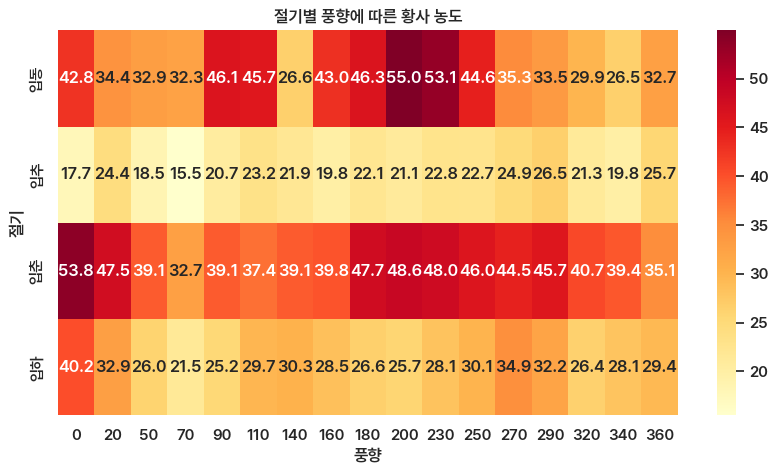

In [32]:
pivot = data.pivot_table(
    values='1시간평균 미세먼지농도(㎍/㎥)',
    index='절기',
    columns='풍향(16방위)',
    aggfunc='mean'
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd'
)

plt.title('절기별 풍향에 따른 황사 농도')
plt.xlabel('풍향')
plt.ylabel('절기')
plt.show()

In [33]:
bins = [0, 0.3, 1.5, 3.3, 5.5, 7.9, 10.7, float('inf')]
labels = ['0~0.3', '0.3~1.5', '1.5~3.3', '3.3~5.5', '5.5~7.9', '7.9~10.7','10.7+']

data['풍속구간'] = pd.cut(data['풍속(m/s)'], bins=bins, labels=labels)

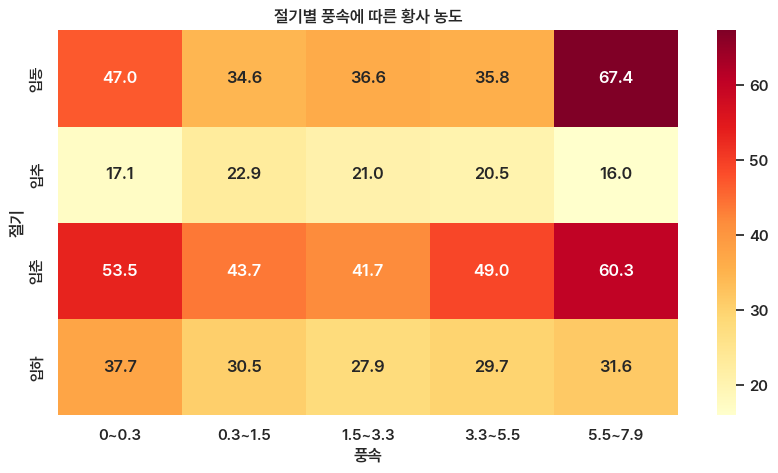

In [34]:
pivot = data.pivot_table(
    values='1시간평균 미세먼지농도(㎍/㎥)',
    index='절기',
    columns='풍속구간',
    aggfunc='mean'
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd'
)

plt.title('절기별 풍속에 따른 황사 농도')
plt.xlabel('풍속')
plt.ylabel('절기')
plt.show()

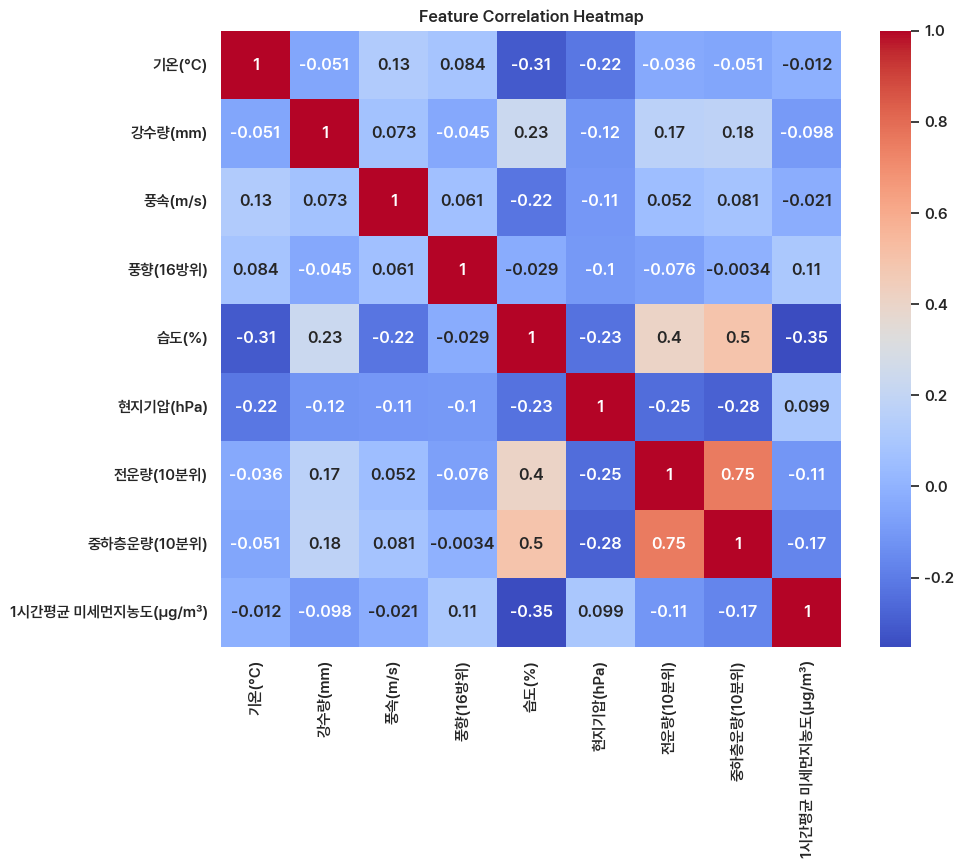

In [35]:
ipha2 = ipha.drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = ipha2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [36]:
ipha2.columns

Index(['기온(°C)', '강수량(mm)', '풍속(m/s)', '풍향(16방위)', '습도(%)', '현지기압(hPa)',
       '전운량(10분위)', '중하층운량(10분위)', '1시간평균 미세먼지농도(㎍/㎥)'],
      dtype='str')

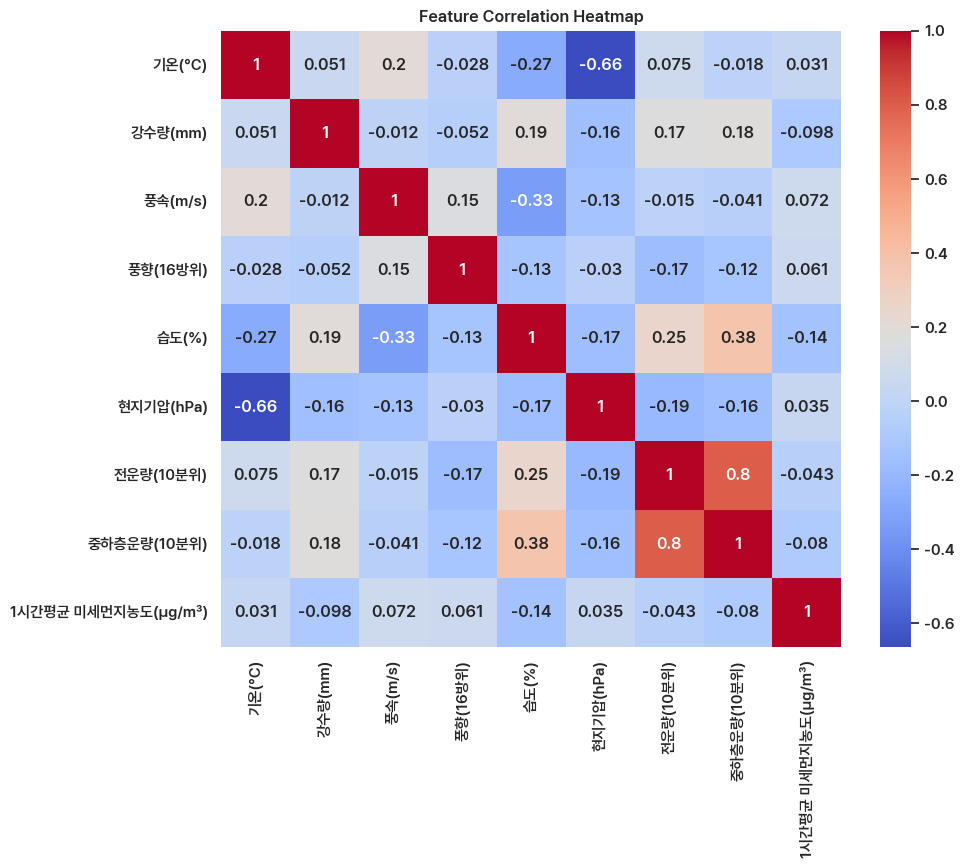

In [37]:
ipchoon2 = ipchoon.drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = ipchoon2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

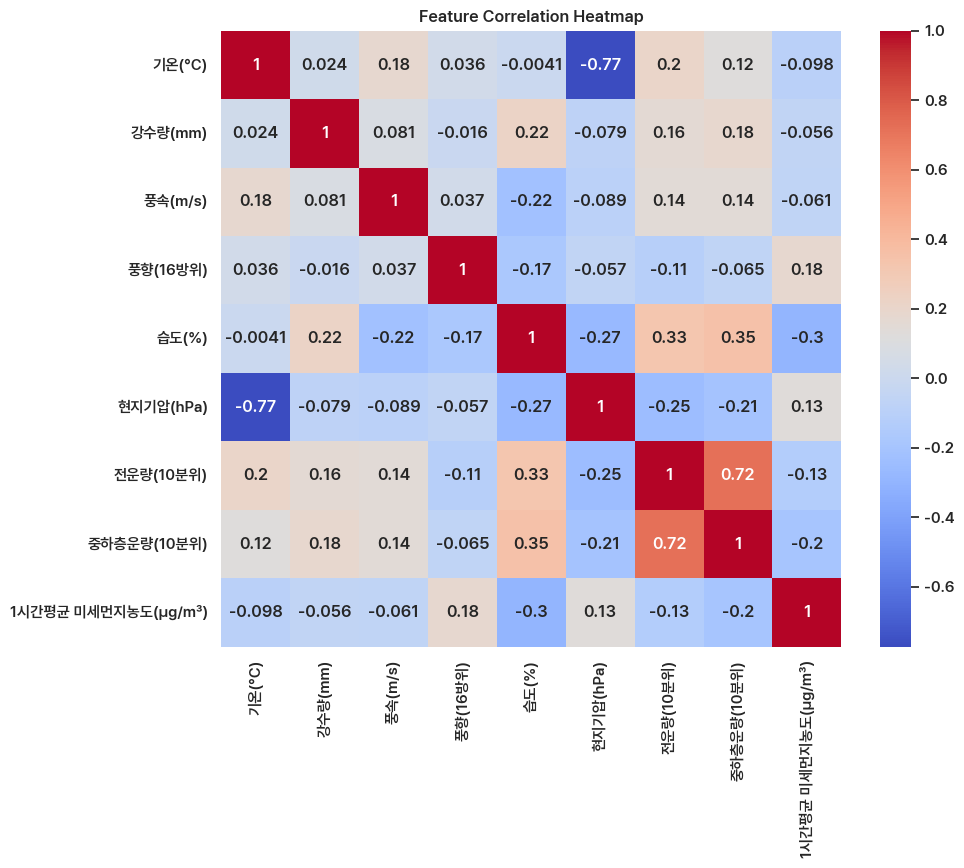

In [38]:
ipchoo2 = ipchoo.drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = ipchoo2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

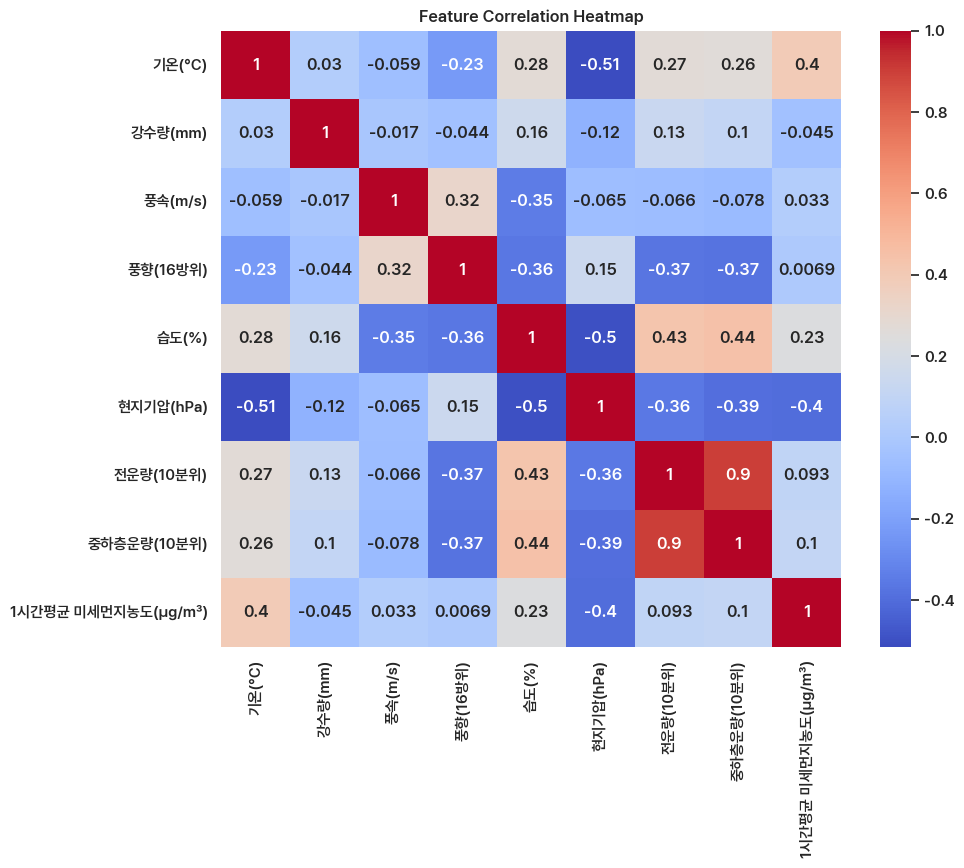

In [39]:
ipdong2 = ipdong.drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = ipdong2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [40]:
data['일시'] = pd.to_datetime(data['일시'])
data['시간'] = data['일시'].dt.hour

pivot = data.pivot_table(
    values='1시간평균 미세먼지농도(㎍/㎥)',
    index='시간',
    columns='계절',
    aggfunc='mean'
)

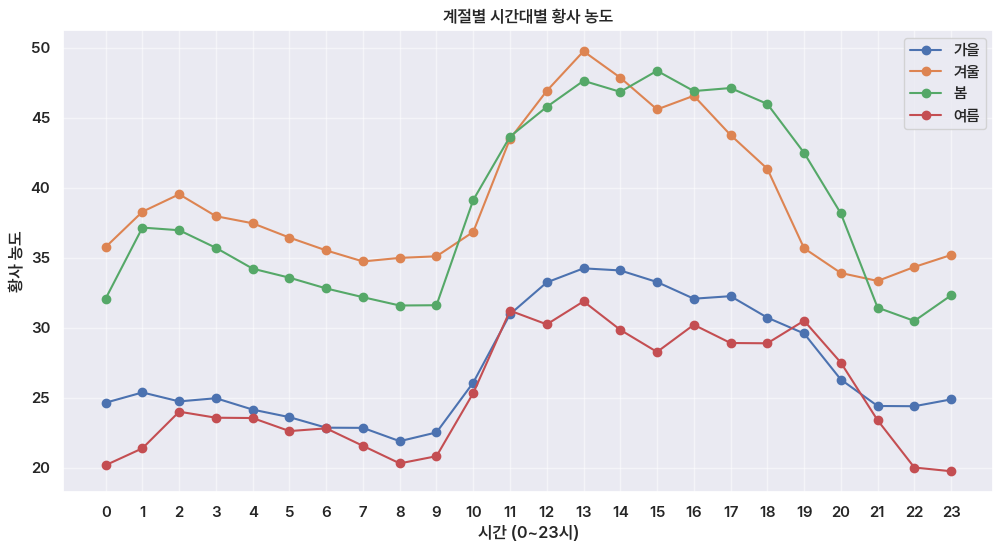

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for season in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[season],
        marker='o',
        label=season
    )

plt.title('계절별 시간대별 황사 농도')
plt.xlabel('시간 (0~23시)')
plt.ylabel('황사 농도')
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

In [42]:
pivot.columns

Index(['가을', '겨울', '봄', '여름'], dtype='str', name='계절')

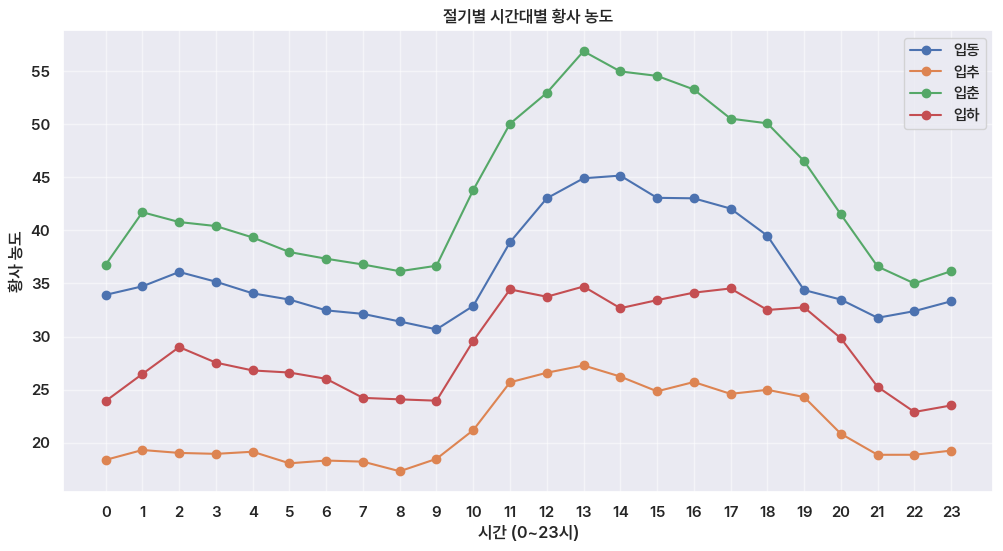

In [43]:
data['일시'] = pd.to_datetime(data['일시'])
data['시간'] = data['일시'].dt.hour

pivot = data.pivot_table(
    values='1시간평균 미세먼지농도(㎍/㎥)',
    index='시간',
    columns='절기',
    aggfunc='mean'
)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for season in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[season],
        marker='o',
        label=season
    )

plt.title('절기별 시간대별 황사 농도')
plt.xlabel('시간 (0~23시)')
plt.ylabel('황사 농도')
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

In [44]:
data.head()

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥),연도,월,일,시각,계절,절기,풍속구간,시간
0,108,서울,2025-04-20 01:00:00,11.6,0.0,1.0,270,93,999.4,0,0,16,2025,4,20,1,봄,입춘,0.3~1.5,1
1,108,서울,2025-04-20 02:00:00,11.2,0.0,1.3,290,94,999.2,0,0,12,2025,4,20,2,봄,입춘,0.3~1.5,2
2,108,서울,2025-04-20 03:00:00,10.6,0.0,2.2,270,95,999.6,2,2,17,2025,4,20,3,봄,입춘,1.5~3.3,3
3,108,서울,2025-04-20 04:00:00,10.1,0.0,1.4,250,93,999.6,0,0,10,2025,4,20,4,봄,입춘,0.3~1.5,4
4,108,서울,2025-04-20 05:00:00,9.7,0.0,0.6,320,94,999.9,0,0,19,2025,4,20,5,봄,입춘,0.3~1.5,5


In [45]:
ipchoon.head()

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥),연도,월,일,시각,계절,절기
0,108,서울,2025-04-20 01:00:00,11.6,0.0,1.0,270,93,999.4,0,0,16,2025,4,20,1,봄,입춘
1,108,서울,2025-04-20 02:00:00,11.2,0.0,1.3,290,94,999.2,0,0,12,2025,4,20,2,봄,입춘
2,108,서울,2025-04-20 03:00:00,10.6,0.0,2.2,270,95,999.6,2,2,17,2025,4,20,3,봄,입춘
3,108,서울,2025-04-20 04:00:00,10.1,0.0,1.4,250,93,999.6,0,0,10,2025,4,20,4,봄,입춘
4,108,서울,2025-04-20 05:00:00,9.7,0.0,0.6,320,94,999.9,0,0,19,2025,4,20,5,봄,입춘


In [47]:
ipchoon[ipchoon['시각']==5]

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥),연도,월,일,시각,계절,절기
4,108,서울,2025-04-20 05:00:00,9.7,0.0,0.6,320,94,999.9,0,0,19,2025,4,20,5,봄,입춘
28,108,서울,2025-04-21 05:00:00,14.3,0.0,2.4,50,80,1004.9,0,0,27,2025,4,21,5,봄,입춘
52,108,서울,2025-04-22 05:00:00,19.6,0.0,1.4,360,81,996.9,10,8,24,2025,4,22,5,봄,입춘
79,108,서울,2025-04-24 05:00:00,11.6,0.0,2.7,250,85,997.4,1,0,20,2025,4,24,5,봄,입춘
103,108,서울,2025-04-25 05:00:00,7.9,0.0,1.3,270,58,1003.9,0,0,47,2025,4,25,5,봄,입춘
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8132,108,서울,2026-04-14 05:00:00,15.2,0.0,1.6,70,51,1003.3,8,0,48,2026,4,14,5,봄,입춘
8156,108,서울,2026-04-15 05:00:00,14.3,0.0,1.1,250,52,1002.2,6,0,53,2026,4,15,5,봄,입춘
8180,108,서울,2026-04-16 05:00:00,13.7,0.0,3.1,70,58,1007.8,0,0,10,2026,4,16,5,봄,입춘
8204,108,서울,2026-04-17 05:00:00,16.4,0.0,1.1,180,27,1004.7,7,0,9,2026,4,17,5,봄,입춘


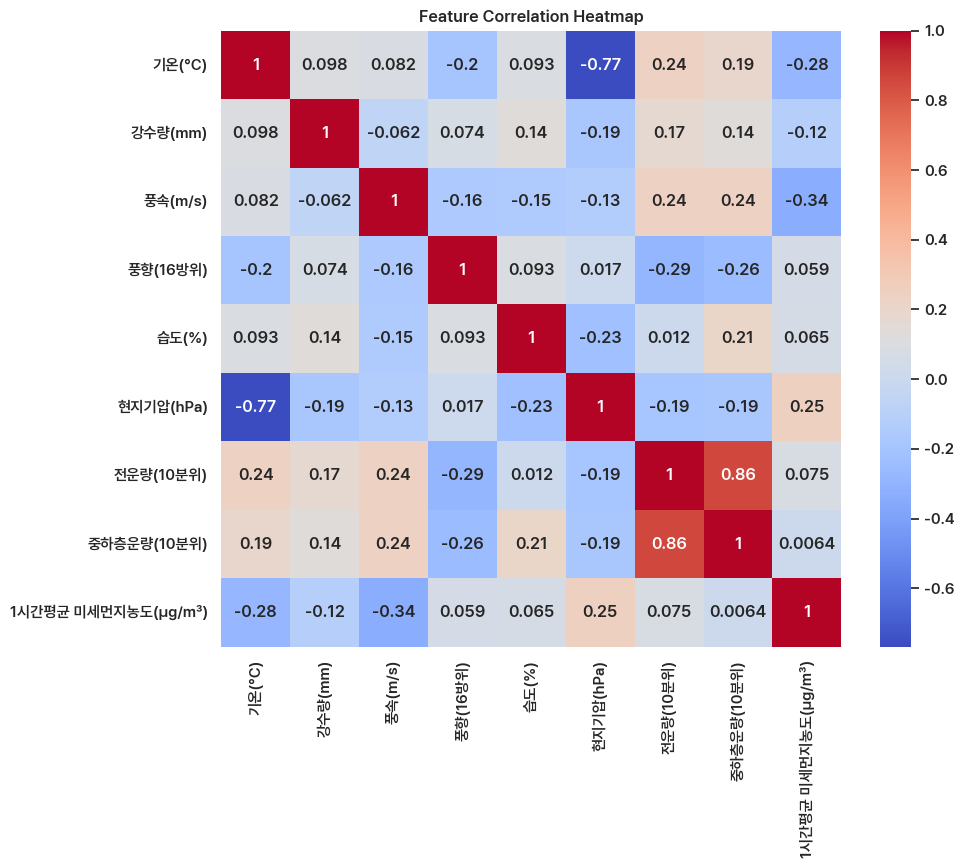

In [51]:
ipchoon3 = ipchoon[ipchoon['시각']==5].drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기' ])

corr_matrix = ipchoon3.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

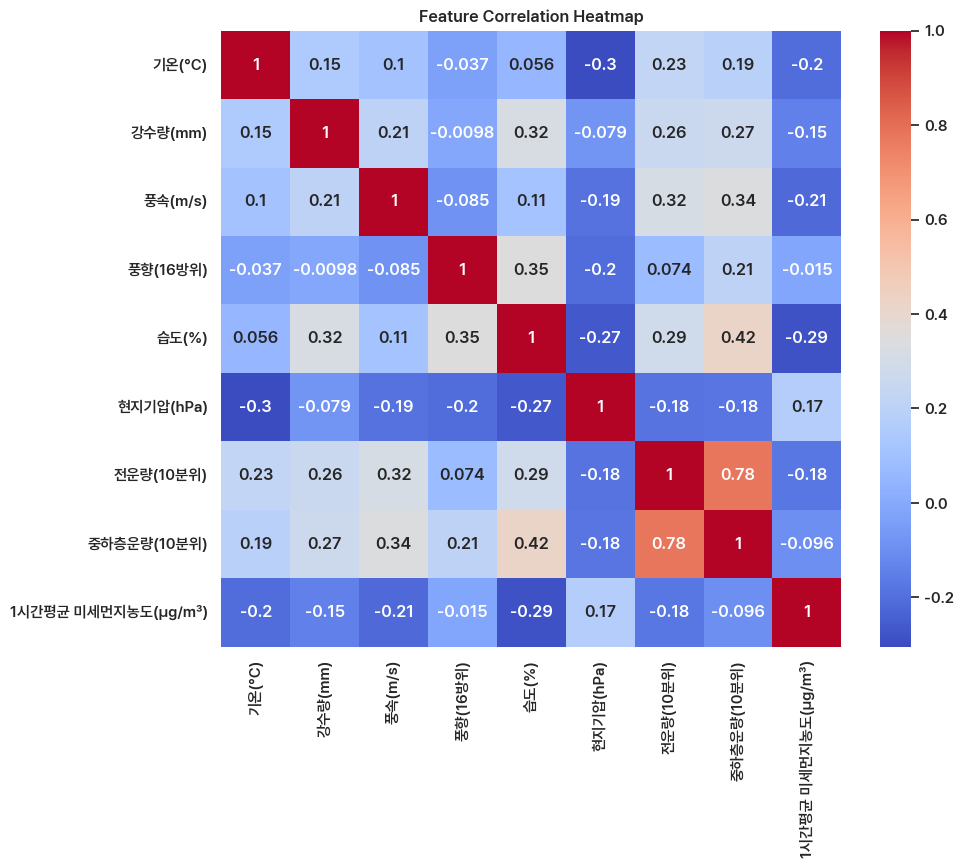

In [53]:
ipha3 = ipha[ipha['시각']==5].drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = ipha3.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

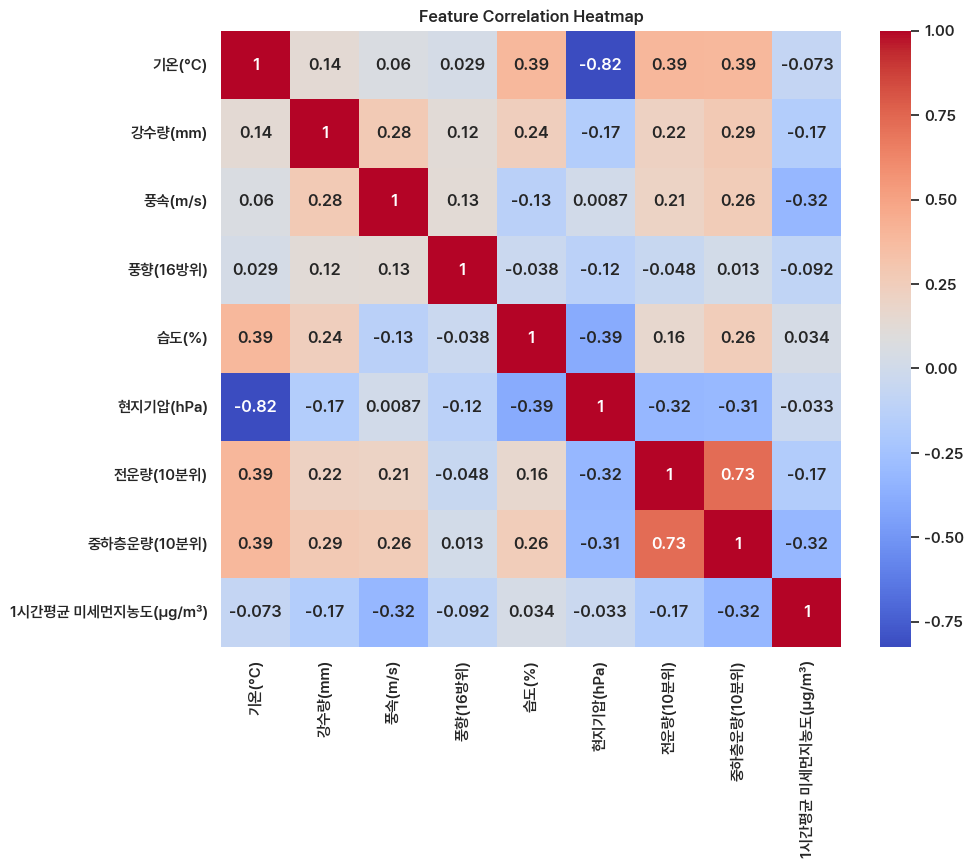

In [54]:
ipchoo3 = ipchoo[ipchoo['시각']==5].drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = ipchoo3.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

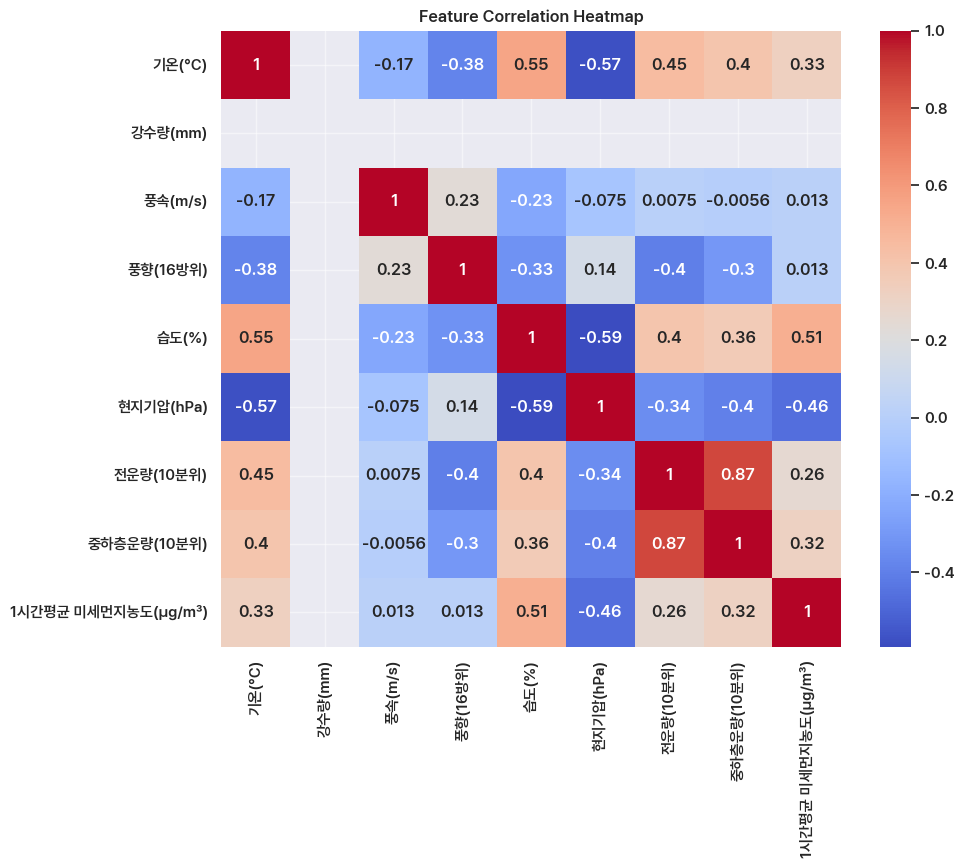

In [55]:
ipdong3 = ipdong[ipdong['시각']==5].drop(columns=['지점명', '지점', '일시', '계절', '연도', '월', '일', '시각', '절기'])

corr_matrix = ipdong3.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [66]:
ipha2 = ipha

In [67]:
ipha2 = pd.get_dummies(ipha2, columns = ['연도', '월', '시각', '계절', '절기'], drop_first=True)
ipha2

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),...,시각_15,시각_16,시각_17,시각_18,시각_19,시각_20,시각_21,시각_22,시각_23,계절_여름
337,108,서울,2025-05-05 00:00:00,11.1,0.0,1.1,230,70,1003.8,0,...,False,False,False,False,False,False,False,False,False,False
338,108,서울,2025-05-05 01:00:00,10.8,0.0,2.2,230,72,1004.2,0,...,False,False,False,False,False,False,False,False,False,False
339,108,서울,2025-05-05 02:00:00,10.2,0.0,0.6,250,75,1003.9,2,...,False,False,False,False,False,False,False,False,False,False
340,108,서울,2025-05-05 03:00:00,9.7,0.0,1.2,50,80,1003.7,7,...,False,False,False,False,False,False,False,False,False,False
341,108,서울,2025-05-05 04:00:00,9.4,0.0,1.8,20,80,1003.3,7,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2484,108,서울,2025-08-06 15:00:00,27.0,7.2,3.0,270,94,990.5,10,...,True,False,False,False,False,False,False,False,False,True
2485,108,서울,2025-08-06 20:00:00,26.1,0.0,2.3,270,87,989.8,1,...,False,False,False,False,False,True,False,False,False,True
2486,108,서울,2025-08-06 21:00:00,25.8,0.0,2.8,270,90,990.7,7,...,False,False,False,False,False,False,True,False,False,True
2487,108,서울,2025-08-06 22:00:00,25.8,0.0,2.8,250,89,991.0,3,...,False,False,False,False,False,False,False,True,False,True


In [60]:
.

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),중하층운량(10분위),1시간평균 미세먼지농도(㎍/㎥),연도,월,일,시각,계절,절기
337,108,서울,2025-05-05 00:00:00,11.1,0.0,1.1,230,70,1003.8,0,0,35,2025,5,5,0,봄,입하
338,108,서울,2025-05-05 01:00:00,10.8,0.0,2.2,230,72,1004.2,0,0,40,2025,5,5,1,봄,입하
339,108,서울,2025-05-05 02:00:00,10.2,0.0,0.6,250,75,1003.9,2,1,38,2025,5,5,2,봄,입하
340,108,서울,2025-05-05 03:00:00,9.7,0.0,1.2,50,80,1003.7,7,0,31,2025,5,5,3,봄,입하
341,108,서울,2025-05-05 04:00:00,9.4,0.0,1.8,20,80,1003.3,7,5,27,2025,5,5,4,봄,입하
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2484,108,서울,2025-08-06 15:00:00,27.0,7.2,3.0,270,94,990.5,10,8,24,2025,8,6,15,여름,입하
2485,108,서울,2025-08-06 20:00:00,26.1,0.0,2.3,270,87,989.8,1,1,20,2025,8,6,20,여름,입하
2486,108,서울,2025-08-06 21:00:00,25.8,0.0,2.8,270,90,990.7,7,7,14,2025,8,6,21,여름,입하
2487,108,서울,2025-08-06 22:00:00,25.8,0.0,2.8,250,89,991.0,3,3,20,2025,8,6,22,여름,입하


In [75]:
from sklearn. model_selection import train_test_split
import numpy as np
y_ipha2 = np.log1p(ipha2['1시간평균 미세먼지농도(㎍/㎥)'])
x_ipha2 = ipha2.drop(columns={'지점', '지점명', '일시',  '1시간평균 미세먼지농도(㎍/㎥)'})
x_train, x_test, y_train, y_test = train_test_split(x_ipha2, y_ipha2, test_size=0.2, random_state=0)


In [76]:
ipha2

,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),풍향(16방위),습도(%),현지기압(hPa),전운량(10분위),...,시각_15,시각_16,시각_17,시각_18,시각_19,시각_20,시각_21,시각_22,시각_23,계절_여름
337,108,서울,2025-05-05 00:00:00,11.1,0.0,1.1,230,70,1003.8,0,...,False,False,False,False,False,False,False,False,False,False
338,108,서울,2025-05-05 01:00:00,10.8,0.0,2.2,230,72,1004.2,0,...,False,False,False,False,False,False,False,False,False,False
339,108,서울,2025-05-05 02:00:00,10.2,0.0,0.6,250,75,1003.9,2,...,False,False,False,False,False,False,False,False,False,False
340,108,서울,2025-05-05 03:00:00,9.7,0.0,1.2,50,80,1003.7,7,...,False,False,False,False,False,False,False,False,False,False
341,108,서울,2025-05-05 04:00:00,9.4,0.0,1.8,20,80,1003.3,7,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2484,108,서울,2025-08-06 15:00:00,27.0,7.2,3.0,270,94,990.5,10,...,True,False,False,False,False,False,False,False,False,True
2485,108,서울,2025-08-06 20:00:00,26.1,0.0,2.3,270,87,989.8,1,...,False,False,False,False,False,True,False,False,False,True
2486,108,서울,2025-08-06 21:00:00,25.8,0.0,2.8,270,90,990.7,7,...,False,False,False,False,False,False,True,False,False,True
2487,108,서울,2025-08-06 22:00:00,25.8,0.0,2.8,250,89,991.0,3,...,False,False,False,False,False,False,False,True,False,True


In [77]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = lr.predict(x_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"스케일링 전 RMSE: {rmse}, R2: {r2}")

스케일링 전 RMSE: 14.026697224861278, R2: 0.14574471462943095


In [78]:
import numpy as np
y_ipha2 = np.log1p(ipha2['1시간평균 미세먼지농도(㎍/㎥)'])
x_ipha2 = ipha2.drop(columns={'지점', '지점명', '일시',  '1시간평균 미세먼지농도(㎍/㎥)'})
x_train, x_test, y_train, y_test = train_test_split(x_ipha2, y_ipha2, test_size=0.2, random_state=0)

lr = LinearRegression()
lr.fit(x_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = lr.predict(x_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"스케일링 전 RMSE: {rmse}, R2: {r2}")

스케일링 전 RMSE: 0.5450781185589487, R2: 0.18162673530101014


In [81]:
pd.Series(lr.coef_, index=x_ipha2.columns).sort_values()

계절_여름         -0.277486
월_7           -0.218902
풍속(m/s)       -0.115107
월_8           -0.111534
시각_22         -0.033710
강수량(mm)       -0.015582
중하층운량(10분위)   -0.010677
습도(%)         -0.009609
현지기압(hPa)     -0.007254
일             -0.004250
풍향(16방위)       0.000689
시각_23          0.006361
전운량(10분위)      0.006781
기온(°C)         0.012641
시각_21          0.026804
월_6            0.052949
시각_1           0.089552
시각_9           0.131248
시각_8           0.201443
시각_7           0.224241
시각_4           0.245082
시각_2           0.263639
시각_16          0.267669
시각_20          0.270713
시각_3           0.296176
시각_18          0.299710
시각_5           0.309544
시각_10          0.315012
시각_14          0.325272
시각_19          0.327727
시각_15          0.356618
시각_6           0.357964
시각_12          0.365824
시각_13          0.378181
시각_11          0.407767
시각_17          0.407954
dtype: float64

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [83]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = lr.predict(x_test_scaled)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"스케일링 후 RMSE: {rmse}, R2: {r2}")

스케일링 후 RMSE: 0.5450781185589489, R2: 0.1816267353010098
